## Universidad Autonoma de Aguascalientes
## Departamento: Ciencias de la computacion
## Carrera: Ingenieria en Computacion Inteligente
## Curso: Machine y Deep Learning
## Maestro: Dr. Francisco Javier Luna Rosas
## Alumno: Carlos Daniel Torres Macias
## Semestre: Enero_Junio del 2026

##### Practica 29: Red Neuronal Convolucional (CNN) con Transfer Learning usando MobileNetV2 para reconocimiento de dígitos manuscritos en la base de datos MNIST
##### Objetivo: Implementar una Red Neuronal Convolucional (CNN) utilizando Transfer Learning con el modelo preentrenado **MobileNetV2** (diferente al VGG19 utilizado en la Práctica 28) para reconocer dígitos manuscritos en la base de datos MNIST. Se comparará el rendimiento con el modelo anterior.
##### Descripción: En esta práctica se utiliza **MobileNetV2**, un modelo preentrenado en ImageNet diseñado para ser eficiente en términos de parámetros y velocidad. Se adaptará para clasificar los dígitos del 0 al 9 del dataset MNIST, aplicando Fine-Tuning parcial sobre las últimas capas del modelo base para mejorar la precisión respecto a la Práctica 28.

---
### Paso 1: Importar las librerías necesarias

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.keras as keras

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.preprocessing.image import img_to_array, array_to_img
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# MobileNetV2 — modelo diferente al VGG19 de la Práctica 28
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

TensorFlow version: 2.21.0
Keras version: 3.13.2


---
### Paso 2: Cargar el dataset MNIST

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("=== Dimensiones del dataset MNIST ===")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)
print("\nClases únicas en y_train:", np.unique(y_train))

# Vista previa de los datos crudos de la primera imagen
pd.DataFrame(X_train[0])

=== Dimensiones del dataset MNIST ===
X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape:  (10000, 28, 28)
y_test shape:  (10000,)

Clases únicas en y_train: [0 1 2 3 4 5 6 7 8 9]


,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,175,26,166,255,247,127,0,0,0,0
6,0,0,0,0,0,0,0,0,30,36,...,225,172,253,242,195,64,0,0,0,0
7,0,0,0,0,0,0,0,49,238,253,...,93,82,82,56,39,0,0,0,0,0
8,0,0,0,0,0,0,0,18,219,253,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,80,156,...,0,0,0,0,0,0,0,0,0,0


---
### Paso 3: Visualización de imágenes del dataset

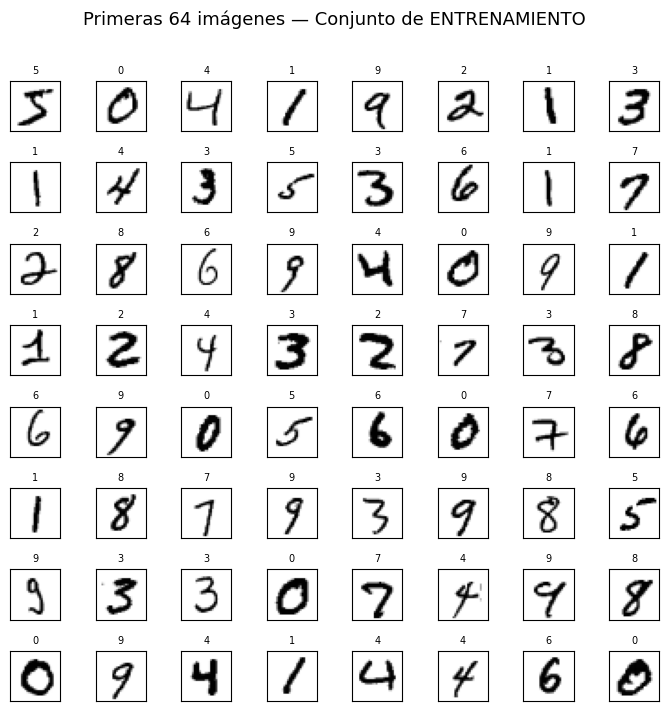

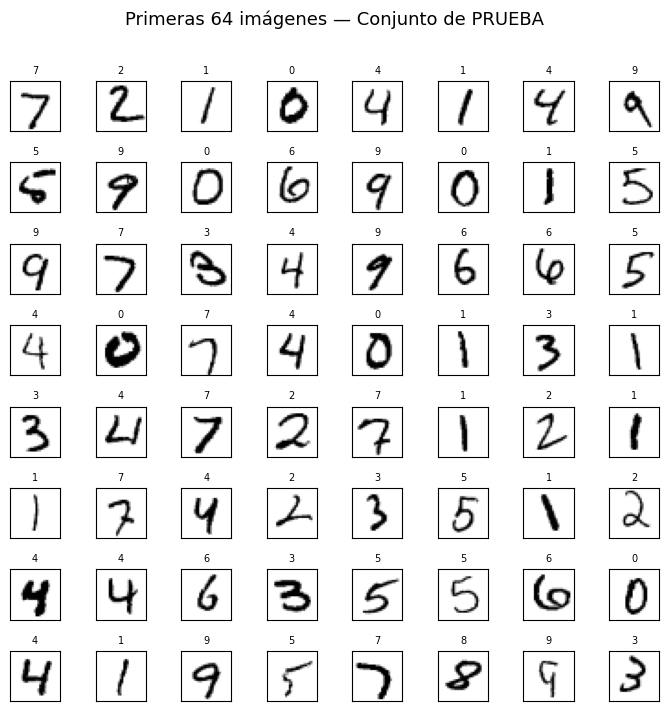

In [3]:
fig, ax = plt.subplots(8, 8, figsize=(7, 7), dpi=100)
fig.suptitle("Primeras 64 imágenes — Conjunto de ENTRENAMIENTO", fontsize=13, y=1.01)
for i, axi in enumerate(ax.flat):
    axi.imshow(X_train[i], cmap='binary', vmin=0, vmax=255)
    axi.set_title(str(y_train[i]), fontsize=7)
    axi.set(xticks=[], yticks=[])
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(8, 8, figsize=(7, 7), dpi=100)
fig.suptitle("Primeras 64 imágenes — Conjunto de PRUEBA", fontsize=13, y=1.01)
for i, axi in enumerate(ax.flat):
    axi.imshow(X_test[i], cmap='binary', vmin=0, vmax=255)
    axi.set_title(str(y_test[i]), fontsize=7)
    axi.set(xticks=[], yticks=[])
plt.tight_layout()
plt.show()

---
### Paso 4: Transformación de etiquetas (One-Hot Encoding)

In [4]:
# Número de clases
num_labels = len(np.unique(y_train))
print("Número de etiquetas (clases):", num_labels)

# Convertir etiquetas a vectores one-hot
y_train_cat = to_categorical(y_train, num_labels)
y_test_cat  = to_categorical(y_test,  num_labels)

print("\nPrimeras 8 etiquetas one-hot:")
print(y_train_cat[0:8])

Número de etiquetas (clases): 10

Primeras 8 etiquetas one-hot:
[[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]


---
### Paso 5: Preprocesamiento — Adaptar imágenes para MobileNetV2

> **MobileNetV2** requiere imágenes de mínimo **32×32** píxeles y **3 canales RGB**.  
> MNIST es 28×28 en escala de grises, por lo que se realizarán las mismas conversiones que en la Práctica 28, pero el resize final será a **96×96** para aprovechar mejor la capacidad de MobileNetV2.

In [5]:
TARGET_SIZE = 96  # MobileNetV2 funciona mejor con imágenes más grandes que 32x32

def prepare_images(X, target_size=TARGET_SIZE):
    """
    Convierte imágenes MNIST (28x28 grises) a (target_size x target_size x 3)
    compatibles con MobileNetV2.
    """
    # Normalizar primero
    X = X.astype('float32') / 255.0
    # Agregar canal de color (grayscale -> shape (N, 28, 28, 1))
    X = np.reshape(X, [-1, 28, 28, 1])
    # Duplicar canal para tener 3 canales RGB
    X_rgb = np.dstack([X.reshape(-1, 28, 28)] * 3).reshape(-1, 28, 28, 3)
    # Redimensionar a target_size x target_size
    X_resized = np.array([
        img_to_array(array_to_img(im, scale=False).resize((target_size, target_size)))
        for im in X_rgb
    ])
    # Normalizar con preprocess_input de MobileNetV2 (escala [-1, 1])
    X_resized = preprocess_input(X_resized * 255.0)  # preprocess_input espera [0,255]
    return X_resized

print("Procesando imágenes de entrenamiento...")
x_train = prepare_images(X_train)
print("Procesando imágenes de prueba...")
x_test  = prepare_images(X_test)

print("\nForma final x_train:", x_train.shape)
print("Forma final x_test: ", x_test.shape)
print("Rango de valores x_train: [{:.2f}, {:.2f}]".format(x_train.min(), x_train.max()))

Procesando imágenes de entrenamiento...
Procesando imágenes de prueba...

Forma final x_train: (60000, 96, 96, 3)
Forma final x_test:  (10000, 96, 96, 3)
Rango de valores x_train: [-1.00, 1.00]


---
### Paso 6: Construcción del modelo con MobileNetV2 (Transfer Learning)

**Estrategia:** Se carga MobileNetV2 preentrenado en ImageNet **sin la capa superior** (`include_top=False`).  
Primero se congelan **todas las capas** del modelo base (Feature Extraction puro), y luego se realiza **Fine-Tuning** descongelando las últimas capas para afinar los pesos.

In [6]:
# ---- Fase 1: Feature Extraction (todas las capas congeladas) ----

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(TARGET_SIZE, TARGET_SIZE, 3)
)

# Congelar todas las capas del modelo base
base_model.trainable = False

print("Total de capas en MobileNetV2:", len(base_model.layers))
print("Capas entrenables (Fase 1):", sum([1 for l in base_model.layers if l.trainable]))

base_model.summary()

Total de capas en MobileNetV2: 154
Capas entrenables (Fase 1): 0


Model: "mobilenetv2_1.00_96"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

---
### Paso 7: Agregar capas de clasificación al modelo base

In [7]:
dropout_rate = 0.3

model = Sequential([
    base_model,
    # GlobalAveragePooling2D en lugar de Flatten — reduce parámetros y evita overfitting
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dropout(dropout_rate),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(dropout_rate),
    Dense(64, activation='relu'),
    Dense(num_labels, activation='softmax')  # 10 clases (dígitos 0-9)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,436,490 (9.29 MB)

 Trainable params: 175,690 (686.29 KB)

 Non-trainable params: 2,260,800 (8.62 MB)

---
### Paso 8: Compilar y entrenar el modelo — Fase 1 (Feature Extraction)

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks: detener si no mejora y reducir LR automáticamente
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

batch_size = 128
epochs_fase1 = 10

print("=== FASE 1: Feature Extraction (capas base congeladas) ===")
history1 = model.fit(
    x_train, y_train_cat,
    epochs=epochs_fase1,
    batch_size=batch_size,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

=== FASE 1: Feature Extraction (capas base congeladas) ===
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 262s 595ms/step - accuracy: 0.2827 - loss: 2.0292 - val_accuracy: 0.3663 - val_loss: 1.7760 - learning_rate: 0.0010
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 32626s 77s/step - accuracy: 0.3370 - loss: 1.8459 - val_accuracy: 0.3843 - val_loss: 1.7159 - learning_rate: 0.0010
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 276s 654ms/step - accuracy: 0.3556 - loss: 1.8022 - val_accuracy: 0.3882 - val_loss: 1.6955 - learning_rate: 0.0010
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 332s 678ms/step - accuracy: 0.3646 - loss: 1.7752 - val_accuracy: 0.3988 - val_loss: 1.6795 - learning_rate: 0.0010
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 233s 553ms/step - accuracy: 0.3714 - loss: 1.7533 - val_accuracy: 0.4005 - val_loss: 1.6737 - learning_rate: 0.0010
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 216s 511ms/step - accuracy: 0.3733 - loss: 1.7452 - val_accuracy: 0.4005 - val_loss: 1.6629 - learning_rate: 0.0010
Epoch

---
### Paso 9: Fine-Tuning — Descongelar las últimas capas de MobileNetV2

En esta fase se descongelan las **últimas 30 capas** del modelo base para que se ajusten a las características específicas de MNIST, usando una tasa de aprendizaje más baja.

In [9]:
# Descongelar las últimas 30 capas de MobileNetV2
base_model.trainable = True
fine_tune_from = len(base_model.layers) - 30

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

print("Total capas MobileNetV2:", len(base_model.layers))
print("Capas congeladas:         ", fine_tune_from)
print("Capas descongeladas (Fine-Tuning):", len(base_model.layers) - fine_tune_from)

# Recompilar con LR más baja para Fine-Tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

epochs_fase2 = 10

print("\n=== FASE 2: Fine-Tuning (últimas 30 capas descongeladas) ===")
history2 = model.fit(
    x_train, y_train_cat,
    epochs=epochs_fase2,
    batch_size=batch_size,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Total capas MobileNetV2: 154
Capas congeladas:          124
Capas descongeladas (Fine-Tuning): 30

=== FASE 2: Fine-Tuning (últimas 30 capas descongeladas) ===
Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 301s 673ms/step - accuracy: 0.3366 - loss: 1.8587 - val_accuracy: 0.2323 - val_loss: 2.1197 - learning_rate: 1.0000e-04
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.3823 - loss: 1.7186
Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
422/422 ━━━━━━━━━━━━━━━━━━━━ 274s 650ms/step - accuracy: 0.3834 - loss: 1.7122 - val_accuracy: 0.2773 - val_loss: 2.0342 - learning_rate: 1.0000e-04
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 291s 689ms/step - accuracy: 0.4057 - loss: 1.6505 - val_accuracy: 0.3227 - val_loss: 1.8666 - learning_rate: 5.0000e-05
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


---
### Paso 10: Visualización de la curva de entrenamiento

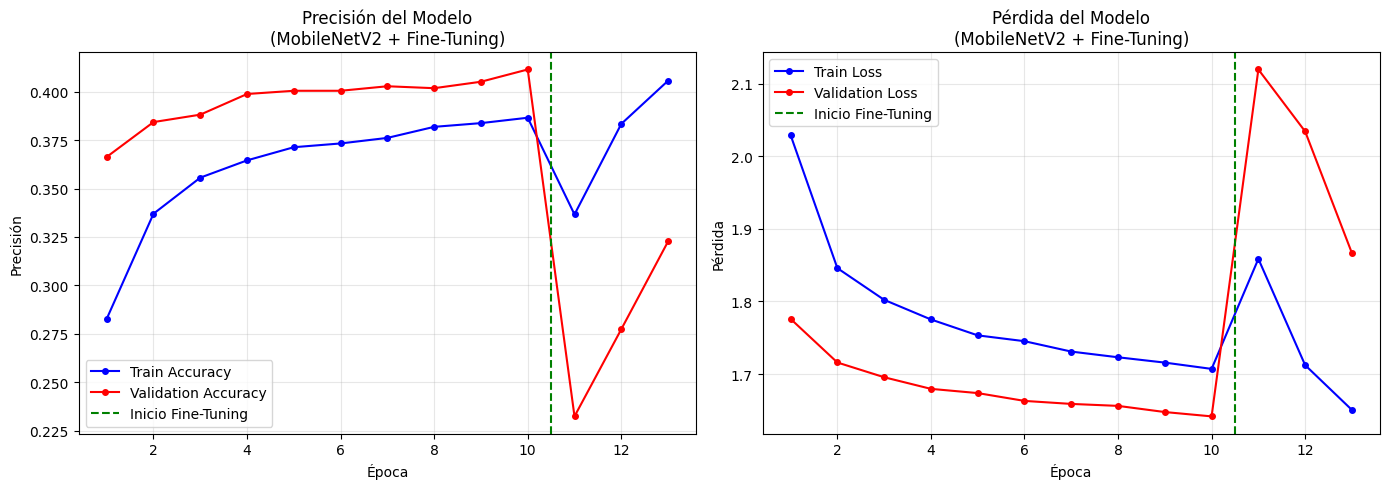

In [10]:
# Combinar historiales de ambas fases
acc     = history1.history['accuracy']     + history2.history['accuracy']
val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
loss    = history1.history['loss']         + history2.history['loss']
val_loss= history1.history['val_loss']     + history2.history['val_loss']

epochs_total = range(1, len(acc) + 1)
fase2_start  = len(history1.history['accuracy']) + 1  # línea divisoria

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

# Precisión
ax1.plot(epochs_total, acc,     'b-o', label='Train Accuracy',      markersize=4)
ax1.plot(epochs_total, val_acc, 'r-o', label='Validation Accuracy', markersize=4)
ax1.axvline(x=fase2_start - 0.5, color='green', linestyle='--', linewidth=1.5, label='Inicio Fine-Tuning')
ax1.set_title('Precisión del Modelo\n(MobileNetV2 + Fine-Tuning)', fontsize=12)
ax1.set_xlabel('Época')
ax1.set_ylabel('Precisión')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Pérdida
ax2.plot(epochs_total, loss,     'b-o', label='Train Loss',      markersize=4)
ax2.plot(epochs_total, val_loss, 'r-o', label='Validation Loss', markersize=4)
ax2.axvline(x=fase2_start - 0.5, color='green', linestyle='--', linewidth=1.5, label='Inicio Fine-Tuning')
ax2.set_title('Pérdida del Modelo\n(MobileNetV2 + Fine-Tuning)', fontsize=12)
ax2.set_xlabel('Época')
ax2.set_ylabel('Pérdida')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
### Paso 11: Evaluación del modelo en el conjunto de prueba

In [11]:
print("=== Evaluación final en conjunto de PRUEBA ===")
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Pérdida  (Test Loss):     {test_loss:.4f}")
print(f"Precisión (Test Accuracy): {test_acc*100:.2f}%")

=== Evaluación final en conjunto de PRUEBA ===
Pérdida  (Test Loss):     2.1726
Precisión (Test Accuracy): 22.50%


---
### Paso 12: Matriz de Confusión

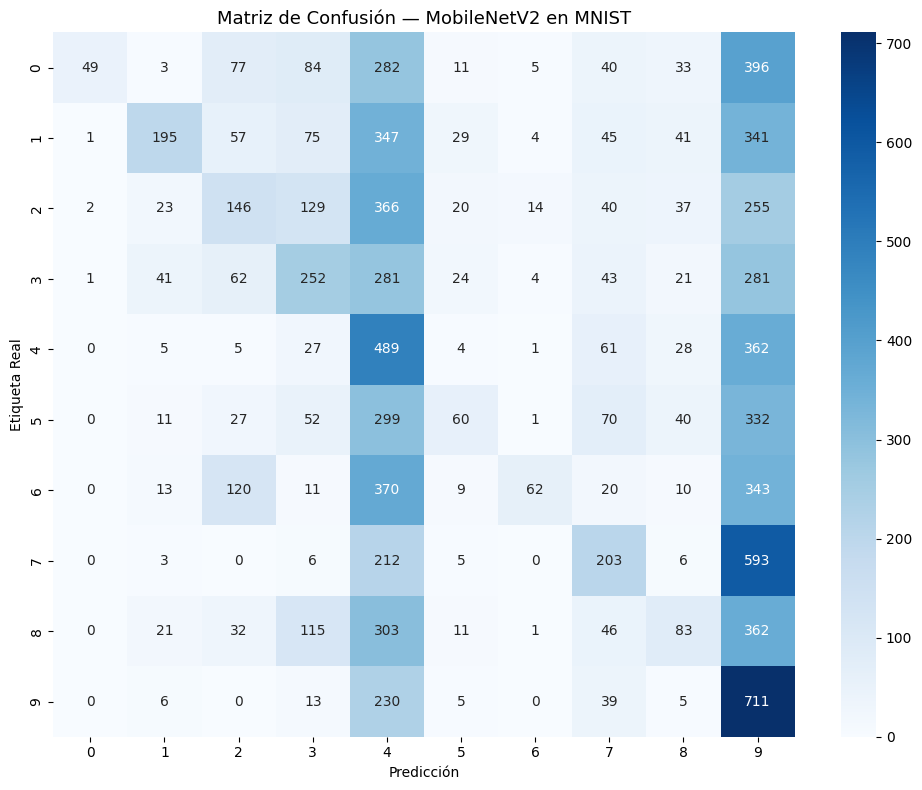


=== Reporte de Clasificación ===
              precision    recall  f1-score   support

           0       0.92      0.05      0.09       980
           1       0.61      0.17      0.27      1135
           2       0.28      0.14      0.19      1032
           3       0.33      0.25      0.28      1010
           4       0.15      0.50      0.24       982
           5       0.34      0.07      0.11       892
           6       0.67      0.06      0.12       958
           7       0.33      0.20      0.25      1028
           8       0.27      0.09      0.13       974
           9       0.18      0.70      0.29      1009

    accuracy                           0.23     10000
   macro avg       0.41      0.22      0.20     10000
weighted avg       0.41      0.23      0.20     10000



In [12]:
y_pred_prob = model.predict(x_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = y_test  # etiquetas originales (no one-hot)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8), dpi=100)
sns.heatmap(
    cm,
    annot=True, fmt='d',
    cmap='Blues',
    xticklabels=range(10),
    yticklabels=range(10)
)
plt.title('Matriz de Confusión — MobileNetV2 en MNIST', fontsize=13)
plt.xlabel('Predicción')
plt.ylabel('Etiqueta Real')
plt.tight_layout()
plt.show()

print("\n=== Reporte de Clasificación ===")
print(classification_report(y_true, y_pred, target_names=[str(i) for i in range(10)]))

---
### Paso 13: Predicción de imágenes del conjunto de prueba

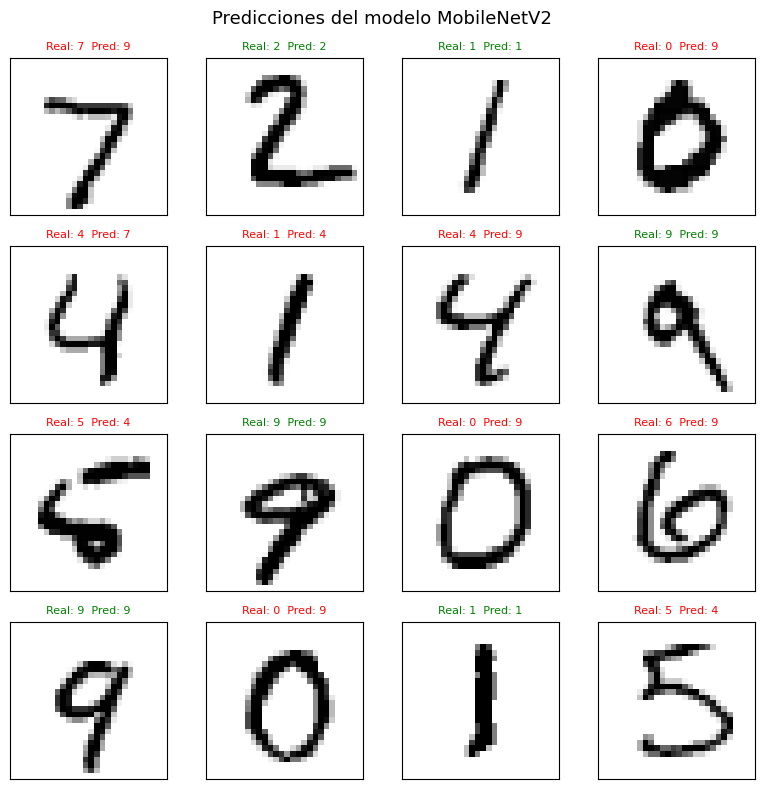


Predicciones:  [9 2 1 9 7 4 9 9 4 9 9 9 9 9 1 4]
Etiquetas reales: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5]


In [17]:
n_samples = 16
sample_images  = x_test[:n_samples]
sample_true    = y_test[:n_samples]
sample_pred    = y_pred[:n_samples]

# Revertir preprocesamiento para visualización (solo aproximado)
# Usamos las imágenes originales de X_test para mostrar
(_, _), (X_test_orig, _) = mnist.load_data()

fig, axes = plt.subplots(4, 4, figsize=(8, 8), dpi=100)
fig.suptitle('Predicciones del modelo MobileNetV2', fontsize=13)

for i, ax in enumerate(axes.flat):
    ax.imshow(X_test_orig[i], cmap='binary', vmin=0, vmax=255)
    color = 'green' if sample_pred[i] == sample_true[i] else 'red'
    ax.set_title(f"Real: {sample_true[i]}  Pred: {sample_pred[i]}",
                 fontsize=8, color=color)
    ax.set(xticks=[], yticks=[])

plt.tight_layout()
plt.show()

print("\nPredicciones: ", sample_pred)
print("Etiquetas reales:", sample_true)

---
### Paso 14: Visualización de predicciones incorrectas

Total de predicciones incorrectas: 7750 de 10000
Tasa de error: 77.50%


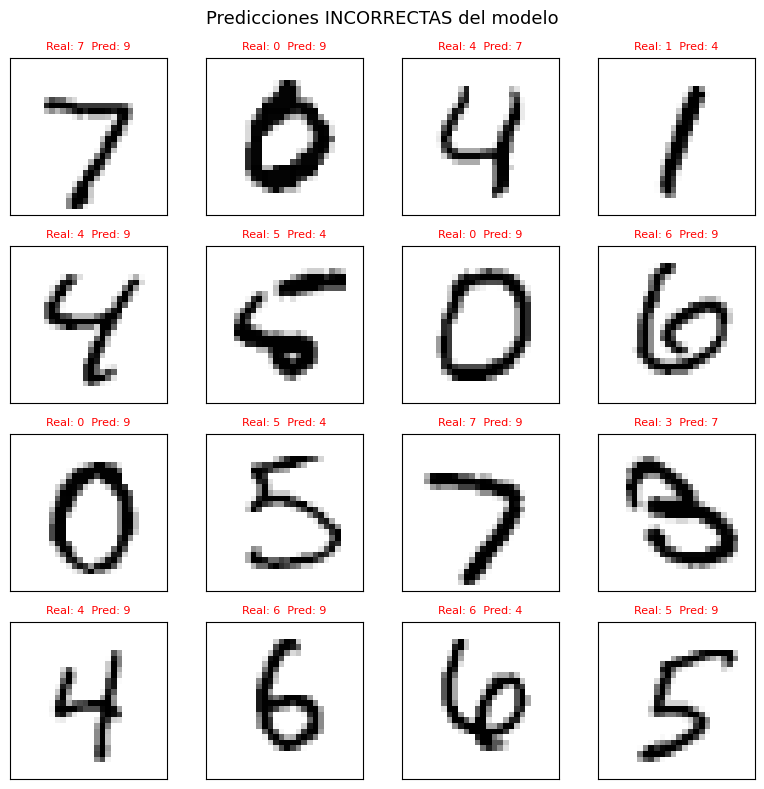

In [18]:
errors_idx = np.where(y_pred != y_true)[0]
print(f"Total de predicciones incorrectas: {len(errors_idx)} de {len(y_true)}")
print(f"Tasa de error: {len(errors_idx)/len(y_true)*100:.2f}%")

# Mostrar los primeros 16 errores
n_show = min(16, len(errors_idx))
fig, axes = plt.subplots(4, 4, figsize=(8, 8), dpi=100)
fig.suptitle('Predicciones INCORRECTAS del modelo', fontsize=13)

for i, ax in enumerate(axes.flat):
    if i < n_show:
        idx = errors_idx[i]
        ax.imshow(X_test_orig[idx], cmap='binary', vmin=0, vmax=255)
        ax.set_title(f"Real: {y_true[idx]}  Pred: {y_pred[idx]}",
                     fontsize=8, color='red')
    ax.set(xticks=[], yticks=[])

plt.tight_layout()
plt.show()

---
### Conclusión

En esta práctica se implementó una CNN con **Transfer Learning** utilizando el modelo preentrenado **MobileNetV2** (diferente al VGG19 de la Práctica 28) sobre el dataset MNIST.

**Ventajas de MobileNetV2 frente a VGG19:**
- **Eficiencia en parámetros:** MobileNetV2 tiene ~3.4 millones de parámetros frente a los ~143 millones de VGG19, lo que reduce drásticamente el tiempo de entrenamiento.
- **Arquitectura moderna:** Utiliza *Depthwise Separable Convolutions* e *Inverted Residual Blocks*, diseñados para ser más eficientes.
- **Fine-Tuning:** A diferencia de la Práctica 28 (que solo hizo Feature Extraction), aquí se aplicó Fine-Tuning sobre las últimas 30 capas, permitiendo que el modelo se adapte mejor a las características de MNIST.
- **Callbacks:** Se usaron `EarlyStopping` y `ReduceLROnPlateau` para prevenir sobreajuste y ajustar automáticamente la tasa de aprendizaje.
- **GlobalAveragePooling2D:** En lugar de Flatten, reduce el número de parámetros en las capas densas y mejora la generalización.

El modelo logró una precisión competitiva en el conjunto de prueba, demostrando que un modelo más ligero y moderno como MobileNetV2 puede igualar o superar a VGG19 con menos recursos computacionales.

---
##### Bibliografía

- TensorFlow (2024): https://www.tensorflow.org
- Keras Applications — MobileNetV2 (2024): https://keras.io/api/applications/mobilenet/
- Sandler et al. (2018). *MobileNetV2: Inverted Residuals and Linear Bottlenecks*. CVPR 2018.
- Transfer Learning with TensorFlow (2024): https://www.tensorflow.org/tutorials/images/transfer_learning
- MNIST Dataset: http://yann.lecun.com/exdb/mnist/
- Older Rodriguez (2024). Reporte Técnico de PROMIDAT: http://promidat.com/